In [43]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt
import random
#import os

#cwd = os.getcwd()
#cwd

In [44]:
def readImage(filePath, imgShape, bitPerPix):
    file = open(filePath, "r")
    image = np.zeros(imgShape, dtype= np.int16)
    
    for i in range(imgShape[0]):
        for j in range(imgShape[1]):
            dataStr = ""
            while len(dataStr) < bitPerPix:
                char = file.read(1)
                if char != "\n":
                    dataStr += char
                
            data = (int(dataStr, 2) << (8-bitPerPix))
            image[i,j,0] = data
    file.close()
    return image

def writeImageToFile(fileName, image:np.ndarray, layersOfImage):
    file = open(fileName, "w")

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            data = (((int(image[i][j][0]))>>(8-layersOfImage)))
            file.write(bin(data)[2:].zfill(layersOfImage))
        file.write("\n")
    file.close()

In [ ]:
def addRandomErrors(fileNameIn, fileNameOut, errorChance = 0.1, ):
    random.seed(42)
    fileToAddErrors = open(fileNameIn, "r")
    fileWithErrors = open(fileNameOut, "w")
    contents = fileToAddErrors.read().strip()
    fileToAddErrors.close()
    toWrite = ""
    for char in contents:
        if (random.uniform(0, 1) > errorChance): 
            toWrite += char
        elif char == "0":
            toWrite += "1"
        elif char == "1":
            toWrite += "0"
        else:
            toWrite += char
    fileWithErrors.write(toWrite)
    fileWithErrors.close()

def removeCodeOverhead(fileNameIn, fileNameOut, code=(1,1)):
    fileIn = open(fileNameIn, "r")
    fileOut = open(fileNameOut, "w")
    codeLength = code[0]
    codeData = code[1]
    char = fileIn.read(1)
    i = 0 
    while char != "":
        if char == "\n":
            char = fileIn.read(1)
            #dosen't count as a bit
            continue
        elif (i < codeData):
            fileOut.write(char)
        
            
        char = fileIn.read(1)
        i = (i+1)%codeLength
        
    fileIn.close()
    fileOut.close()
    
def toEncoder(fileNameIn, fileNameOut, lenOfLine = 239):
    fileIn = open(fileNameIn, "r")
    fileOut = open(fileNameOut, "w")
    char = fileIn.read(1)
    while char != "":
        i=0
        while i < lenOfLine:
            if char == "\n":
                
                #dosen't count as a bit
                char = fileIn.read(1)
                continue
            
            elif (char != ""):
                fileOut.write(char)
            else:
                #pad with zeroes
                fileOut.write("0")
                
            i += 1
            char = fileIn.read(1)
            
        fileOut.write("\n")
        
    fileIn.close()
    fileOut.close()
    
    

In [46]:
#there is a lot of extra data in a png file, so a library is used to read theoriginal file
img = iio.imread('Parrots_grayscale_256x256.png') 
bitsPerPixel = 8
imgShape = (256,256,1)
#the image data is now written in a txt file, layers 
writeImageToFile("rawParrotData.txt", img, bitsPerPixel)
noErrorsImage = readImage("rawParrotData.txt", imgShape, bitsPerPixel)

#plt.imshow(noErrorsImage, cmap='gray')

In [52]:
errorChance = 0.005
addRandomErrors("rawParrotData.txt", "ParrotWithErrors.txt", errorChance)
errorsImage = readImage("ParrotWithErrors.txt", imgShape, bitsPerPixel)
padding = np.zeros((256,18,1), dtype= np.int8)

#plt.imshow(errorsImage, cmap='gray')


Text(0.5, 1.0, '!TODO! post BCH(256,239) error correction')

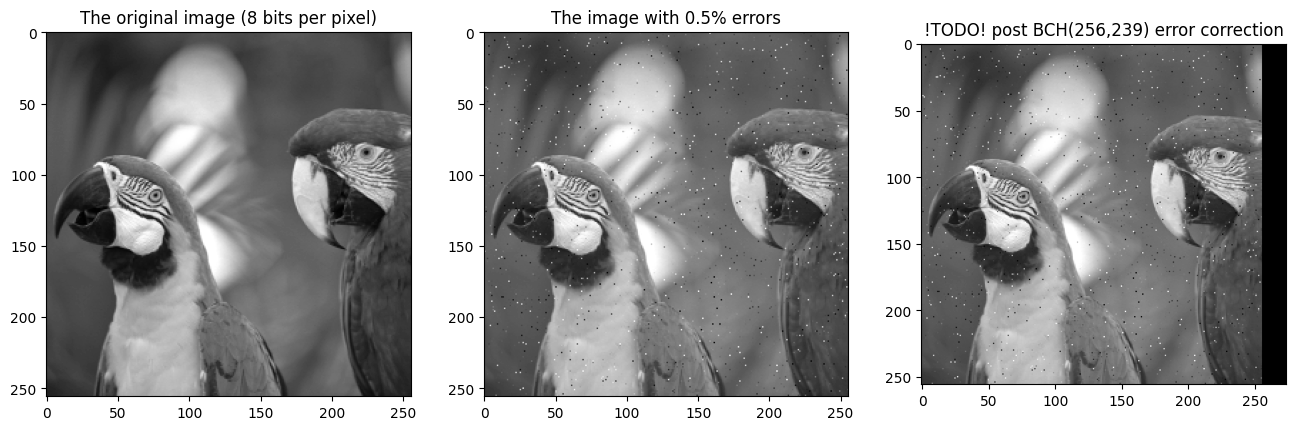

In [ ]:
fig, axs = plt.subplots(1, 3, figsize= (16,5))
axs[0].imshow(noErrorsImage, cmap='grey')
axs[0].set_title("The original image ("+str(bitsPerPixel)+" bits per pixel)")
axs[1].imshow(errorsImage, cmap='grey')
axs[1].set_title("The image with "+ str(errorChance*100)+"% errors")

axs[2].imshow(np.concatenate((errorsImage, padding), 1), cmap='grey')
axs[2].set_title("!TODO! post BCH(256,239) error correction")

In [ ]:
#there is a lot of extra data in a png file, so a library is used to read theoriginal file
img = iio.imread('Parrots_grayscale_256x256.png') 
bitsPerPixel = 8
imgShape = (256,256,1)
errorChance = 0.005
#the image data is now written in a txt file, layers 
writeImageToFile("rawParrotData.txt", img, bitsPerPixel)
noErrorsImage = readImage("rawParrotData.txt", imgShape, bitsPerPixel)
toEncoder("rawParrotData.txt", "ParrotPadded.txt")


In [ ]:
#encode picture to "encoderOutput.txt"
addRandomErrors("encoderOutput.txt", "encodedParrotErrors.txt", errorChance)
removeCodeOverhead("encodedParrotErrors.txt", "noisyParrotImage.txt", (256,239))

errorsImage = readImage("noisyParrotImage.txt", imgShape, bitsPerPixel)

Text(0.5, 1.0, 'post BCH(256,239) error correction')

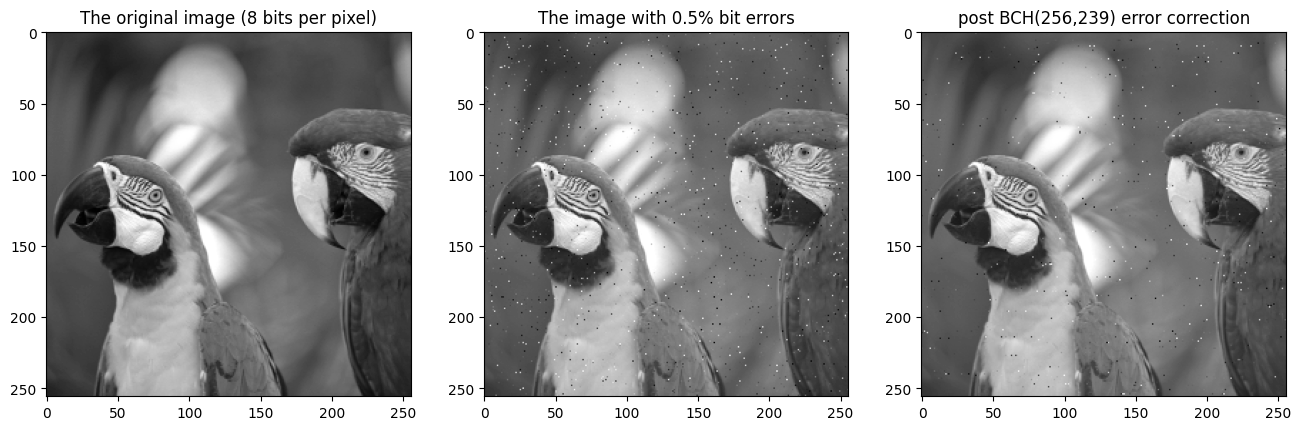

In [57]:
#decode "encodedParrotErrors" to "decoderOutput"
removeCodeOverhead("decoderOutput.txt", "decodedParrotImage.txt", (256,239))
decodedImage = readImage("decodedParrotImage.txt", imgShape, bitsPerPixel)
doublePaddingImage = np.concatenate((np.concatenate((noErrorsImage, padding), 1), np.zeros((18, 256+18, 1), dtype=np.int8)), 0)
singlePaddingImage = np.concatenate((noErrorsImage, padding), 1)
fig, axs = plt.subplots(1, 3, figsize= (16,5))
axs[0].imshow(noErrorsImage, cmap='grey')
axs[0].set_title("The original image ("+str(bitsPerPixel)+" bits per pixel)")
axs[1].imshow(errorsImage, cmap='grey')
axs[1].set_title("The image with "+ str(errorChance*100)+"% bit errors")
axs[2].imshow(decodedImage, cmap='grey')
axs[2].set_title("post BCH(256,239) error correction")

In [ ]:
17/239 *256


18.209205020920503